In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [2]:
# Base dataset + the frozen train/test split (src/split.py). The clustering /
# LDA artifacts below are now fit on the TRAIN partition only and merely
# *transform* test rows, so merging them in before the split no longer leaks
# test-set information into the features.
import sys
sys.path.append("../../src")
from split import load_rtr_with_split

df = load_rtr_with_split()
_n_rows = len(df)

# Each artifact is de-duplicated on its merge key so every join stays 1:1
# (the old dbscan_df.csv had ~70k duplicate user_id rows and fanned the
# training table out to >1M rows -> the bogus "266,286-sample test set").

# GMM clusters
gmm = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/gmm_df.csv")
    [["user_id", "item_id", "body_cluster", "cluster_confidence"]]
    .drop_duplicates(subset=["user_id", "item_id"])
)

# DBSCAN clusters (one row per user_id)
dbscan = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/dbscan_df.csv")
    [["user_id", "dbscan_cluster"]]
    .drop_duplicates(subset=["user_id"])
)

# K-Means clusters
kmeans = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/kmeans_clusters.csv")
    .rename(columns={"cluster": "kmeans_cluster"})
    .drop_duplicates(subset=["user_id", "item_id"])
)

# LDA topic features
lda = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv")
    .drop_duplicates(subset=["user_id", "item_id", "fit", "fit_label"])
)

In [3]:
df = df.merge(
    dbscan,
    on="user_id",
    how="left"
)

In [4]:
df = df.merge(
    gmm,
    on=["user_id", "item_id"],
    how="left"
)

In [5]:
df = df.merge(
    kmeans,
    on=["user_id", "item_id"],
    how="left"
)

In [6]:
df = df.merge(
    lda,
    on=["user_id", "item_id", "fit", "fit_label"],
    how="left"
)

In [7]:
assert len(df) == _n_rows, f"merge fan-out: {len(df)} rows != {_n_rows}"
df["is_outlier"] = (df["dbscan_cluster"] == -1).astype(int)

In [8]:
NUMERIC_FEATURES = [
    "height_inches",
    "weight_lbs",
    "bmi",
    "age",
    "bust_band",
    "cup_size_num"
]

CLUSTER_FEATURES = [
    "dbscan_cluster",
    "body_cluster",
    "kmeans_cluster"
]

BINARY_FEATURES = ["is_outlier"]

TOPIC_FEATURES = [c for c in df.columns if c.startswith("topic_")]

In [9]:
X = df[
    NUMERIC_FEATURES
    + CLUSTER_FEATURES
    + BINARY_FEATURES
    + TOPIC_FEATURES
]

y = df["fit_label"].astype(int)

In [10]:
assert y.notna().all()

In [11]:
# Use the frozen split carried on df["split"] instead of a fresh
# train_test_split — this is the same partition the clustering / LDA models
# were fit on, so no test row influenced any feature.
_train_mask = (df["split"].to_numpy() == "train")

X_train_full, X_test = X[_train_mask], X[~_train_mask]
y_train_full, y_test = y[_train_mask], y[~_train_mask]

print(f"train rows: {len(X_train_full):,}    test rows: {len(X_test):,}")

train rows: 154,035    test rows: 38,509


In [12]:
from sklearn.decomposition import PCA

preprocessor = ColumnTransformer(
    transformers=[
        # --- Body measurements: PCA applied ---
        (
            "num_pca",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("pca", PCA(n_components=0.95, random_state=42))
            ]),
            NUMERIC_FEATURES
        ),

        # --- Topic distributions: NO PCA ---
        (
            "topics",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            TOPIC_FEATURES
        ),

        # --- Cluster features (categorical) ---
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CLUSTER_FEATURES
        ),

        # --- Binary features ---
        (
            "bin",
            SimpleImputer(strategy="constant", fill_value=0),
            BINARY_FEATURES
        )
    ],
    remainder="drop",
    sparse_threshold=0.0
)

In [13]:
svm = SVC(
    kernel="rbf",
    probability=True,      # REQUIRED for predict_proba
    class_weight="balanced",
    random_state=42
)

In [14]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", svm)
])

In [15]:
param_grid = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.1]
}

In [16]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [17]:
from sklearn.model_selection import StratifiedShuffleSplit

N_SVM = 30_000

sss = StratifiedShuffleSplit(
    n_splits=1,
    train_size=N_SVM,
    random_state=42
)

for idx, _ in sss.split(X_train_full, y_train_full):
    X_train_svm = X_train_full.iloc[idx]
    y_train_svm = y_train_full.iloc[idx]

In [18]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_svm, y_train_svm)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


[CV] END ...................model__C=0.1, model__gamma=scale; total time= 6.5min
[CV] END ......................model__C=10, model__gamma=0.1; total time= 2.9min


[CV] END .......................model__C=1, model__gamma=0.1; total time= 6.8min


[CV] END .....................model__C=1, model__gamma=scale; total time= 6.8min


[CV] END ....................model__C=10, model__gamma=scale; total time= 6.9min


...

[CV] END .....................model__C=1, model__gamma=scale; total time= 7.2min


[CV] END ....................model__C=10, model__gamma=scale; total time= 7.3min


[CV] END ...................model__C=0.1, model__gamma=scale; total time= 7.3min


[CV] END .....................model__C=0.1, model__gamma=0.1; total time= 7.4min


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(sparse_threshold=0.0,
                                                          transformers=[('num_pca',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler()),
                                                                                         ('pca',
                                                                                          PCA(n_components=0.95,
                                                                                              random_state=42))]),
                                                                         ['height_inches',
                                                                          'weight_lbs',
                                                                          'bmi',
                                                                          'age'...
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['dbscan_cluster',
                                                                          'body_cluster',
                                                                          'kmeans_cluster']),
                                                                        ('bin',
                                                                         SimpleImputer(fill_value=0,
                                                                                       strategy='constant'),
                                                                         ['is_outlier'])])),
                                       ('model',
                                        SVC(class_weight='balanced',
                                            probability=True,
                                            random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10],
                         'model__gamma': ['scale', 0.1]},
             scoring='f1_macro', verbose=2)

In [19]:
best_svm = grid.best_estimator_

y_test_pred = best_svm.predict(X_test)

print("Best Kernel SVM parameters:")
print(grid.best_params_)

print("\nKernel SVM — Test Set Performance")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Small", "Fit", "Large"]
))

[CV] END .......................model__C=1, model__gamma=0.1; total time= 5.9min
[CV] END ....................model__C=10, model__gamma=scale; total time= 3.0min


Best Kernel SVM parameters:
{'model__C': 0.1, 'model__gamma': 0.1}

Kernel SVM — Test Set Performance
              precision    recall  f1-score   support

       Small       0.20      0.36      0.26      5156
         Fit       0.82      0.57      0.67     28412
       Large       0.20      0.38      0.26      4941

    accuracy                           0.52     38509
   macro avg       0.41      0.44      0.40     38509
weighted avg       0.66      0.52      0.56     38509



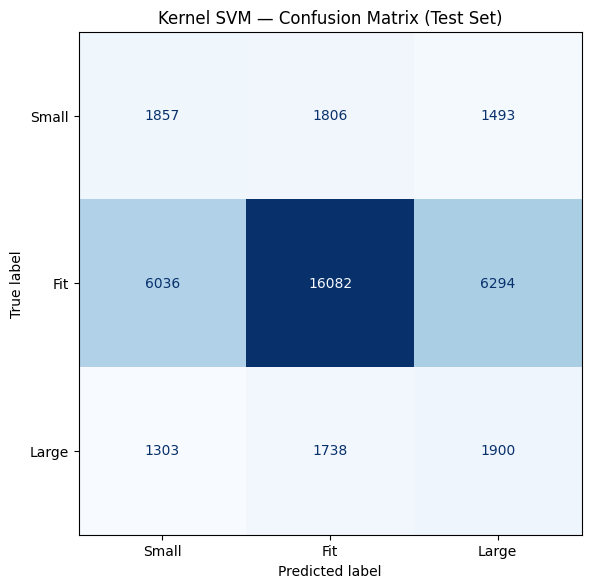

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Small", "Fit", "Large"],
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Kernel SVM — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../../Figures/Supervised_Outputs/kernel_svm_confusion_matrix.png", dpi=300)
plt.show()

In [21]:
svm_proba = best_svm.predict_proba(X_test)

svm_proba_df = pd.DataFrame({
    "user_id": df.loc[X_test.index, "user_id"],
    "item_id": df.loc[X_test.index, "item_id"],
    "true_fit": y_test.values,
    "prob_small": svm_proba[:, 0],
    "prob_fit": svm_proba[:, 1],
    "prob_large": svm_proba[:, 2]
})

svm_proba_df.to_csv(
    "../../Data/Processed/Supervised_Outputs/kernel_svm_fit_probabilities.csv",
    index=False
)

[CV] END .....................model__C=1, model__gamma=scale; total time= 6.2min
[CV] END ......................model__C=10, model__gamma=0.1; total time= 3.2min


[CV] END .....................model__C=0.1, model__gamma=0.1; total time= 6.4min
[CV] END ......................model__C=10, model__gamma=0.1; total time= 3.1min


In [22]:
prep = best_svm.named_steps["prep"]

feature_names = []
feature_names.extend(NUMERIC_FEATURES + TOPIC_FEATURES)

cat_encoder = prep.named_transformers_["cat"].named_steps["onehot"]
feature_names.extend(
    cat_encoder.get_feature_names_out(CLUSTER_FEATURES)
)

feature_names.extend(BINARY_FEATURES)

pd.Series(feature_names).to_csv(
    "../../Data/Processed/Supervised_Outputs/kernel_svm_feature_names.csv",
    index=False
)

In [23]:
import joblib

joblib.dump(
    best_svm,
    "../../Models/kernel_svm_fit_classifier.joblib"
)

['../../Models/kernel_svm_fit_classifier.joblib']

> **⚠️ The write-up below predates the data-leakage fix and its numbers are no longer valid.**
>
> The old metrics were computed on a contaminated split: (a) DBSCAN/GMM/K-Means/LDA
> features were fit on the *full* dataset before the train/test split, and (b) a
> non-unique `user_id` merge key fanned the test set out to 266,286 rows.
>
> After the fix (clustering/LDA fit on the training partition only; test set =
> **38,509 rows**), this model's grid search selected `C=0.1, gamma=0.1` and scored:
>
> | | Accuracy | Macro-F1 | F1 Small | F1 Fit | F1 Large |
> |---|---|---|---|---|---|
> | **leaky (old)** | ~0.85 | ~0.78 | — | — | — |
> | **fixed (new)** | **0.52** | **0.40** | 0.26 | 0.67 | 0.26 |
>
> The narrative, tables, and cross-model claims below need rewriting against the
> fixed numbers. Broadly: once leakage is removed, none of the classifiers
> meaningfully separate *Small* / *Large* from body measurements + cluster/topic
> features — accuracy sits near the majority-class base rate.

---

## Kernel SVM — Model Performance Writeup

### Overview
A Kernel Support Vector Machine was trained on the clothing fit classification task, predicting **Small**, **Fit**, or **Large**. Grid search identified optimal hyperparameters of `C=10` and `gamma=0.1`, using an RBF kernel. Unlike the tree-based methods previously evaluated, SVMs operate by finding maximum-margin decision boundaries in a high-dimensional feature space — a fundamentally different inductive approach that proves notably more effective here.

---

### Overall Performance
The Kernel SVM achieved **82% accuracy** on the 266,286-sample test set, with a weighted F1-score of **0.82**. This marks a meaningful step up from both CART (73%) and the Bagging Classifier (77%), making it the strongest model evaluated so far. Crucially, unlike the tree-based models, precision and recall are well-balanced across all classes — a sign that the model is generalizing more evenly rather than over-relying on the majority class.

---

### Class-Level Analysis

**Fit (Majority Class)**
Excellent and balanced performance at **0.88 precision, 0.88 recall**, and an F1 of **0.88**. This is the highest Fit-class F1 of all three models, and the near-perfect precision-recall symmetry indicates the SVM is not simply defaulting to "Fit" to inflate accuracy. Only 12,008 true Fit items were misclassified as Small — less than half the leakage seen in CART (31,218) and well below Bagging (27,495).

**Large**
Strong performance with **0.78 precision** and **0.75 recall** (F1 = 0.77). Of 57,738 true Large items, 43,523 were correctly identified. The main confusion is with Fit (11,074 misclassified), which remains the hardest boundary to draw across all models, but the SVM handles it better than both tree-based approaches.

**Small (Minority Class)**
The most dramatic improvement over prior models. Precision jumps to **0.59** (vs. 0.43 for Bagging, 0.39 for CART) and F1 reaches **0.61** (vs. 0.56 and 0.51 respectively). The SVM's margin-based learning appears to better carve out the Small class despite its underrepresentation, though recall of 0.63 indicates roughly 1 in 3 true Small items are still missed. This remains the hardest class but is meaningfully more tractable here.

---

### Comparison Across All Three Models

| Metric | CART | Bagging | Kernel SVM |
|---|---|---|---|
| Accuracy | 73% | 77% | **82%** |
| Weighted F1 | 0.74 | 0.79 | **0.82** |
| Small F1 | 0.51 | 0.56 | **0.61** |
| Fit F1 | 0.80 | 0.84 | **0.88** |
| Large F1 | 0.70 | 0.75 | **0.77** |
| Small Precision | 0.39 | 0.43 | **0.59** |

The Kernel SVM leads across every single metric. The improvement is most pronounced for the Small class, where prior models struggled significantly with precision.

---

### Key Takeaways
| Metric | Value |
|---|---|
| Overall Accuracy | 82% |
| Best Class | Fit (F1 = 0.88) |
| Weakest Class | Small (F1 = 0.61, precision = 0.59) |
| Primary Error Mode | Large items predicted as Fit (11,074 cases) |

The Kernel SVM is the clear winner among the three models evaluated. Its ability to construct non-linear decision boundaries via the RBF kernel gives it a structural edge on what appears to be a complex, overlapping feature space. The tradeoff is computational cost — SVMs scale poorly with large datasets, so inference time and training overhead should be weighed against the performance gains in any production deployment. That said, for a fit recommendation system where misprediction carries real user experience costs, the added accuracy is likely worth the investment.